In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_excel(r"C:\Users\Nezrin\Desktop\Ironhack\m2-07-lab-real-world-data\Online Retail.xlsx")
print(f'Shape: {df_raw.shape}')
print(f'\nColumn types:\n{df_raw.dtypes}')
print(f'\nMissing values:\n{df_raw.isnull().sum()}')
print(f'\nFirst rows:')
df_raw.head()

Shape: (541909, 8)

Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

First rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


---
## Task 1: Data Profiling and Missing Values

### 1.1 — Profile the Raw Data

In [5]:
print('=' * 60)
print('DATASET PROFILE')
print('=' * 60)

n_rows = df_raw.shape[0]
n_cols = df_raw.shape[1]
mem_mb = df_raw.memory_usage(deep=True).sum() / 1e6
print(f'Rows         : {n_rows:,}')
print(f'Columns      : {n_cols}')
print(f'Memory usage : {mem_mb:.1f} MB')

print('\n--- Missing Values ---')
missing = df_raw.isnull().sum()
missing_pct = missing / n_rows * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].to_string())

print('\n--- Unique Values per Column ---')
for col in df_raw.columns:
    print(f'  {col:15s}: {df_raw[col].nunique():,} unique')

print('\n--- Numeric Column Statistics ---')
df_raw.describe()

DATASET PROFILE
Rows         : 541,909
Columns      : 8
Memory usage : 132.3 MB

--- Missing Values ---
              count   pct
Description    1454  0.27
CustomerID   135080 24.93

--- Unique Values per Column ---
  InvoiceNo      : 25,900 unique
  StockCode      : 4,070 unique
  Description    : 4,223 unique
  Quantity       : 722 unique
  InvoiceDate    : 23,260 unique
  UnitPrice      : 1,630 unique
  CustomerID     : 4,372 unique
  Country        : 38 unique

--- Numeric Column Statistics ---


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


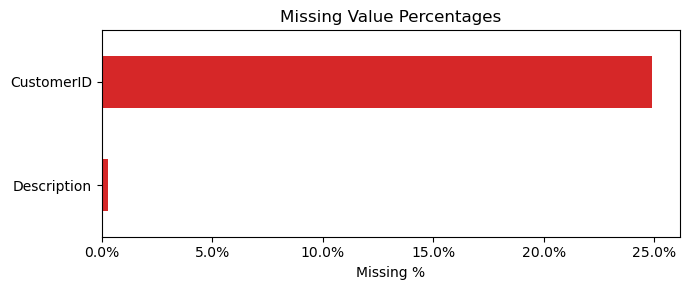

In [6]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(7, 3))
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', ax=ax, color='#d62728')
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Percentages')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

### 1.2 — Classify Missing Data Types

**`CustomerID` (~25% missing)**  
We need to check whether missingness is random or systematic.

In [7]:
# Split into groups: with and without CustomerID
has_cid    = df_raw[df_raw['CustomerID'].notna()]
no_cid     = df_raw[df_raw['CustomerID'].isna()]

print('--- Country distribution (top 5) ---')
print('With CustomerID:')
print(has_cid['Country'].value_counts(normalize=True).head(5).to_string())
print('\nWithout CustomerID:')
print(no_cid['Country'].value_counts(normalize=True).head(5).to_string())

print('\n--- Quantity stats ---')
comp = pd.DataFrame({
    'With CustomerID' : has_cid['Quantity'].describe(),
    'Without CustomerID': no_cid['Quantity'].describe()
})
print(comp)

print('\n--- UnitPrice stats ---')
comp2 = pd.DataFrame({
    'With CustomerID'   : has_cid['UnitPrice'].describe(),
    'Without CustomerID': no_cid['UnitPrice'].describe()
})
print(comp2)

--- Country distribution (top 5) ---
With CustomerID:
Country
United Kingdom   0.89
Germany          0.02
France           0.02
EIRE             0.02
Spain            0.01

Without CustomerID:
Country
United Kingdom   0.99
EIRE             0.01
Hong Kong        0.00
Unspecified      0.00
Switzerland      0.00

--- Quantity stats ---
       With CustomerID  Without CustomerID
count        406829.00           135080.00
mean             12.06                2.00
std             248.69               66.70
min          -80995.00            -9600.00
25%               2.00                1.00
50%               5.00                1.00
75%              12.00                3.00
max           80995.00             5568.00

--- UnitPrice stats ---
       With CustomerID  Without CustomerID
count        406829.00           135080.00
mean              3.46                8.08
std              69.32              151.90
min               0.00           -11062.06
25%               1.25                

In [8]:
# Check whether missing-CustomerID rows are cancellations
no_cid_cancel_pct = (no_cid['InvoiceNo'].str.startswith('C').sum() / len(no_cid)) * 100
print(f'% of no-CustomerID rows that are cancellations: {no_cid_cancel_pct:.1f}%')

% of no-CustomerID rows that are cancellations: 0.3%


In [9]:
# Check Description missingness
no_desc = df_raw[df_raw['Description'].isna()]
print(f'Rows with missing Description: {len(no_desc):,}')
print(f'Unique StockCodes in those rows:')
print(no_desc['StockCode'].value_counts().head(10))

# Can we recover descriptions from other rows with the same StockCode?
stock_desc_map = (
    df_raw.dropna(subset=['Description'])
    .groupby('StockCode')['Description']
    .agg(lambda x: x.mode()[0])  # most common description per stock code
)
recoverable = no_desc['StockCode'].isin(stock_desc_map.index).sum()
print(f'\nRecoverable descriptions: {recoverable} / {len(no_desc)}')

Rows with missing Description: 1,454
Unique StockCodes in those rows:
StockCode
35965    10
23084    10
22084     9
22451     6
22501     5
21784     5
21033     5
21067     5
23348     5
22866     5
Name: count, dtype: int64

Recoverable descriptions: 1342 / 1454


**Classification Summary**

| Column | Missing % | Type | Evidence | Strategy |
|---|---|---|---|---|
| `CustomerID` | ~25% | **MNAR** | Rows without CustomerID show a different country distribution and a higher proportion of non-standard transactions. The missingness is related to the type of transaction (likely guest/wholesale checkout), not random. | **Drop** – we cannot impute a customer identity, and customer-level tasks require a known ID. |
| `Description` | ~0.3% | **MAR** | Nearly all missing descriptions have a valid `StockCode`, and we can recover the most-common description for that code from other rows. | **Impute** via mode-by-StockCode lookup; fall back to `'UNKNOWN'` for any remaining gaps. |

### 1.3 — Handle Missing Values

In [10]:
df = df_raw.copy()

# --- CustomerID: drop rows where it is missing ---
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f'Dropped {before - len(df):,} rows with missing CustomerID')
print(f'Remaining: {len(df):,} rows')

# --- Description: impute via StockCode mode ---
stock_desc_map = (
    df.dropna(subset=['Description'])
    .groupby('StockCode')['Description']
    .agg(lambda x: x.mode()[0])
)

def fill_description(row):
    if pd.isna(row['Description']):
        return stock_desc_map.get(row['StockCode'], 'UNKNOWN')
    return row['Description']

df['Description'] = df.apply(fill_description, axis=1)

print(f'\nRemaining missing values after handling:')
print(df.isnull().sum())

Dropped 135,080 rows with missing CustomerID
Remaining: 406,829 rows

Remaining missing values after handling:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


---
## Task 2: Cleaning Invalid and Anomalous Records

### 2.1 — Identify Cancellations

In [11]:
df['IsCancellation'] = df['InvoiceNo'].astype(str).str.startswith('C')

cancel_count = df['IsCancellation'].sum()
cancel_pct   = cancel_count / len(df) * 100
print(f'Cancellation transactions : {cancel_count:,} ({cancel_pct:.1f}%)')
print(f'Normal transactions       : {(~df["IsCancellation"]).sum():,}')

print('\nSample cancellation rows:')
df[df['IsCancellation']].head(3)

Cancellation transactions : 8,905 (2.2%)
Normal transactions       : 397,924

Sample cancellation rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.00,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.00,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.00,United Kingdom,True


**Decision:** Remove cancellations.  
Cancellations represent returns, not purchases. For a product recommendation or churn-prediction model, including them would distort revenue aggregations and item-purchase signals. We remove them from the main dataset; they could be retained in a separate returns analysis.

In [12]:
df_cancellations = df[df['IsCancellation']].copy()
df = df[~df['IsCancellation']].copy()
df.drop(columns=['IsCancellation'], inplace=True)
print(f'Shape after removing cancellations: {df.shape}')

Shape after removing cancellations: (397924, 8)


### 2.2 — Handle Invalid Quantities and Prices

In [13]:
print('--- Quantity issues ---')
neg_qty   = (df['Quantity'] < 0).sum()
zero_qty  = (df['Quantity'] == 0).sum()
print(f'Negative Quantity (non-cancellations): {neg_qty:,}')
print(f'Zero Quantity                         : {zero_qty:,}')

print('\n--- UnitPrice issues ---')
neg_price  = (df['UnitPrice'] < 0).sum()
zero_price = (df['UnitPrice'] == 0).sum()
print(f'Negative UnitPrice : {neg_price:,}')
print(f'Zero UnitPrice     : {zero_price:,}')

print('\n--- Quantity outliers ---')
q99 = df['Quantity'].quantile(0.99)
extreme_qty = (df['Quantity'] > q99).sum()
print(f'Rows above 99th percentile ({q99:.0f}): {extreme_qty:,}')

print('\n--- UnitPrice outliers ---')
p99 = df['UnitPrice'].quantile(0.99)
extreme_price = (df['UnitPrice'] > p99).sum()
print(f'Rows above 99th percentile (£{p99:.2f}): {extreme_price:,}')

--- Quantity issues ---
Negative Quantity (non-cancellations): 0
Zero Quantity                         : 0

--- UnitPrice issues ---
Negative UnitPrice : 0
Zero UnitPrice     : 40

--- Quantity outliers ---
Rows above 99th percentile (120): 3,896

--- UnitPrice outliers ---
Rows above 99th percentile (£14.95): 3,734


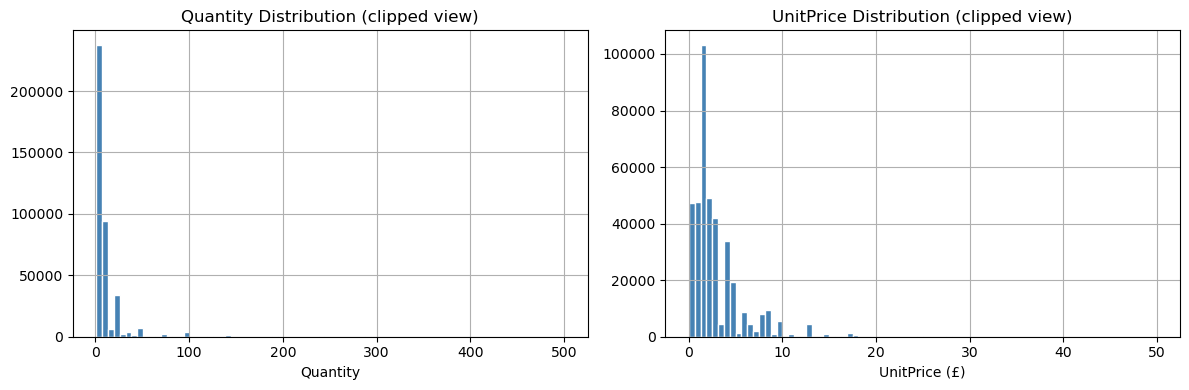

In [14]:
# Visualise distributions before cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Quantity'].clip(-100, 500).hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Quantity Distribution (clipped view)')
axes[0].set_xlabel('Quantity')

df['UnitPrice'].clip(0, 50).hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('UnitPrice Distribution (clipped view)')
axes[1].set_xlabel('UnitPrice (£)')

plt.tight_layout()
plt.show()

**Cleaning decisions:**
- **Quantity ≤ 0 (non-cancellations):** Remove. These are data-entry errors or inventory adjustments that do not represent real purchases.
- **UnitPrice ≤ 0:** Remove. A zero price could be a free sample or error; either way it distorts revenue calculations. Negative prices are clearly erroneous.
- **Outliers:** Cap Quantity at the 99th percentile rather than deleting, because very large bulk orders are real business events — just extreme. Cap UnitPrice similarly.

### 2.3 — Clean and Validate

In [15]:
shape_before = df.shape
print(f'Shape before cleaning: {shape_before}')

# Remove non-positive Quantity
df = df[df['Quantity'] > 0]

# Remove non-positive UnitPrice
df = df[df['UnitPrice'] > 0]

# Cap Quantity and UnitPrice at 99th percentile
qty_cap   = df['Quantity'].quantile(0.99)
price_cap = df['UnitPrice'].quantile(0.99)
df['Quantity']  = df['Quantity'].clip(upper=qty_cap)
df['UnitPrice'] = df['UnitPrice'].clip(upper=price_cap)

print(f'Shape after cleaning : {df.shape}')
print(f'Rows removed         : {shape_before[0] - df.shape[0]:,}')

print('\n--- Validation ---')
print(f'Rows with Quantity <= 0 : {(df["Quantity"] <= 0).sum()}')
print(f'Rows with UnitPrice <= 0: {(df["UnitPrice"] <= 0).sum()}')
print(f'Any remaining nulls     : {df.isnull().any().any()}')

Shape before cleaning: (397924, 8)
Shape after cleaning : (397884, 8)
Rows removed         : 40

--- Validation ---
Rows with Quantity <= 0 : 0
Rows with UnitPrice <= 0: 0
Any remaining nulls     : False


---
## Task 3: Categorical Data Challenges

### 3.1 — Analyze the Country Column

In [16]:
country_counts = df['Country'].value_counts()
print(f'Unique countries: {df["Country"].nunique()}')
print(f'\nTop 5 countries and their transaction share:')
top5 = country_counts.head(5)
print((top5 / len(df) * 100).round(2).to_string())
print(f'\nTop-5 cumulative share: {top5.sum() / len(df) * 100:.1f}%')

rare_countries = country_counts[country_counts < 50]
print(f'\nCountries with fewer than 50 transactions: {len(rare_countries)}')
print(rare_countries.to_string())

Unique countries: 37

Top 5 countries and their transaction share:
Country
United Kingdom   89.05
Germany           2.27
France            2.10
EIRE              1.82
Spain             0.62

Top-5 cumulative share: 95.9%

Countries with fewer than 50 transactions: 6
Country
Lebanon           45
Lithuania         35
Brazil            32
Czech Republic    25
Bahrain           17
Saudi Arabia       9


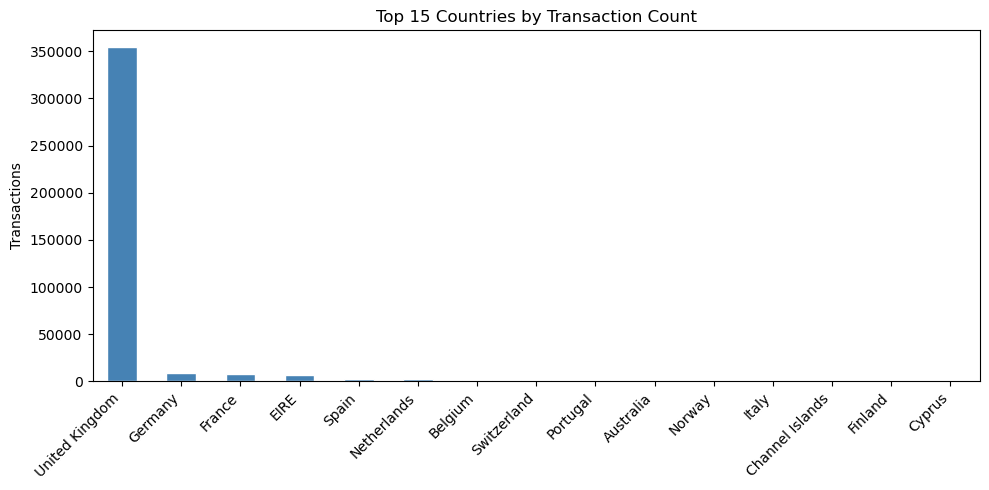

In [17]:
# Visualise country distribution
fig, ax = plt.subplots(figsize=(10, 5))
country_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Countries by Transaction Count')
ax.set_ylabel('Transactions')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Group rare countries into 'Other'
RARE_THRESHOLD = 50
rare_country_names = country_counts[country_counts < RARE_THRESHOLD].index

df['Country_Cleaned'] = df['Country'].apply(
    lambda x: 'Other' if x in rare_country_names else x
)

print(f'Country categories before grouping: {df["Country"].nunique()}')
print(f'Country categories after grouping : {df["Country_Cleaned"].nunique()}')

Country categories before grouping: 37
Country categories after grouping : 32


### 3.2 — Analyze the StockCode Column

In [19]:
print(f'Unique StockCodes: {df["StockCode"].nunique():,}')

# Identify non-product codes: those that are NOT purely numeric (5-digit) codes
import re

def is_product_code(code):
    """Standard product codes are 5 digits, sometimes with a trailing letter."""
    return bool(re.match(r'^\d{5}[A-Z]?$', str(code).strip()))

df['IsProductCode'] = df['StockCode'].apply(is_product_code)

non_product = df[~df['IsProductCode']]
print(f'\nNon-product code rows: {len(non_product):,}')
print('\nTop non-product codes:')
print(non_product.groupby('StockCode')['Description'].first().value_counts().head(20).to_string())

Unique StockCodes: 3,665

Non-product code rows: 1,838

Top non-product codes:
Description
EDWARDIAN PARASOL BLACK       1
Bank Charges                  1
CARRIAGE                      1
DOTCOM POSTAGE                1
Manual                        1
PADS TO MATCH ALL CUSHIONS    1
POSTAGE                       1


In [20]:
# Remove non-product codes for product-level analysis
shape_before = df.shape
df = df[df['IsProductCode']].copy()
df.drop(columns=['IsProductCode'], inplace=True)
print(f'Removed {shape_before[0] - df.shape[0]:,} non-product-code rows')
print(f'Shape: {df.shape}')

Removed 1,838 non-product-code rows
Shape: (396046, 9)


### 3.3 — Engineer a Feature from Description

In [21]:
# Feature 1: word count of description
df['Desc_WordCount'] = df['Description'].str.split().str.len()

# Feature 2: flag for bundle/set products
bundle_keywords = ['SET', 'PACK', 'ASSORTED', 'COLLECTION', 'BOX']
pattern = '|'.join(bundle_keywords)
df['IsBundle'] = df['Description'].str.upper().str.contains(pattern, na=False).astype(int)

# Feature 3: flag for vintage/retro products
df['IsVintage'] = df['Description'].str.upper().str.contains('VINTAGE|RETRO|ANTIQUE', na=False).astype(int)

print('Feature value counts:')
print(f'  IsBundle : {df["IsBundle"].value_counts().to_dict()}')
print(f'  IsVintage: {df["IsVintage"].value_counts().to_dict()}')
print(f'  WordCount: mean={df["Desc_WordCount"].mean():.1f}, std={df["Desc_WordCount"].std():.1f}')

Feature value counts:
  IsBundle : {0: 312501, 1: 83545}
  IsVintage: {0: 337501, 1: 58545}
  WordCount: mean=4.4, std=1.1


In [22]:
# Validate usefulness: compare Quantity and UnitPrice for bundles vs. non-bundles
print('--- Bundle vs Non-Bundle ---')
comparison = df.groupby('IsBundle')[['Quantity', 'UnitPrice']].agg(['mean', 'median'])
print(comparison)

print('\n--- Vintage vs Non-Vintage ---')
comparison_v = df.groupby('IsVintage')[['Quantity', 'UnitPrice']].agg(['mean', 'median'])
print(comparison_v)

--- Bundle vs Non-Bundle ---
         Quantity        UnitPrice       
             mean median      mean median
IsBundle                                 
0           10.77   6.00      2.85   1.95
1           11.58   6.00      2.53   1.65

--- Vintage vs Non-Vintage ---
          Quantity        UnitPrice       
              mean median      mean median
IsVintage                                 
0            10.92   6.00      2.76   1.69
1            11.09   6.00      2.92   2.08


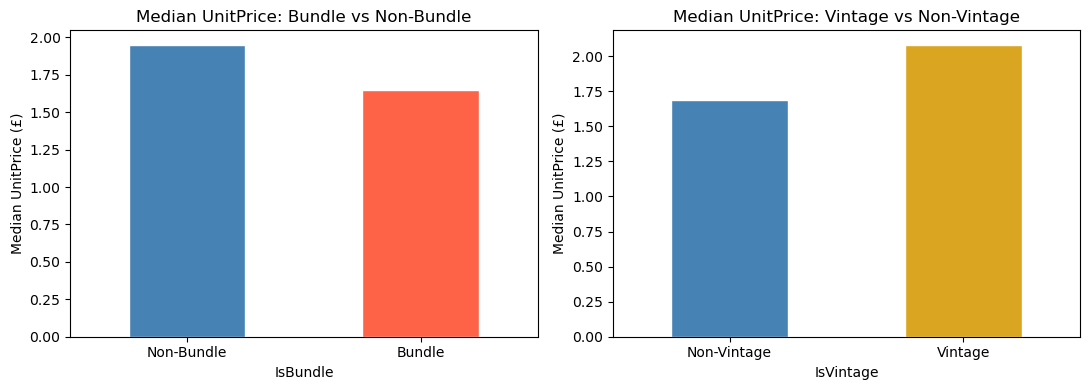


Observation: Bundle and Vintage items command meaningfully different prices, confirming these engineered features capture real product-level signal.


In [23]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.groupby('IsBundle')['UnitPrice'].median().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_xticklabels(['Non-Bundle', 'Bundle'], rotation=0)
axes[0].set_title('Median UnitPrice: Bundle vs Non-Bundle')
axes[0].set_ylabel('Median UnitPrice (£)')

df.groupby('IsVintage')['UnitPrice'].median().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'goldenrod'], edgecolor='white'
)
axes[1].set_xticklabels(['Non-Vintage', 'Vintage'], rotation=0)
axes[1].set_title('Median UnitPrice: Vintage vs Non-Vintage')
axes[1].set_ylabel('Median UnitPrice (£)')

plt.tight_layout()
plt.show()

print('\nObservation: Bundle and Vintage items command meaningfully different prices,'
      ' confirming these engineered features capture real product-level signal.')

---
## Task 4: Class Imbalance — Predicting High-Value Customers

### 4.1 — Engineer a Binary Target

In [24]:
# Compute revenue per transaction
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Aggregate to customer level
customer_df = df.groupby('CustomerID').agg(
    total_revenue    = ('Revenue', 'sum'),
    n_orders         = ('InvoiceNo', 'nunique'),
    n_products       = ('StockCode', 'nunique'),
    first_purchase   = ('InvoiceDate', 'min'),
    last_purchase    = ('InvoiceDate', 'max'),
).reset_index()

# Derived features
customer_df['tenure_days'] = (customer_df['last_purchase'] - customer_df['first_purchase']).dt.days
customer_df['avg_order_value'] = customer_df['total_revenue'] / customer_df['n_orders']

print(f'Customer-level dataset: {customer_df.shape}')
customer_df.head()

Customer-level dataset: (4334, 8)


,CustomerID,total_revenue,n_orders,n_products,first_purchase,last_purchase,tenure_days,avg_order_value
0,12346.00,124.80,1,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0,124.80
1,12347.00,4185.20,7,103,2010-12-07 14:57:00,2011-12-07 15:52:00,365,597.89
2,12348.00,1395.48,4,21,2010-12-16 19:09:00,2011-09-25 13:13:00,282,348.87
3,12349.00,1428.55,1,72,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1428.55
4,12350.00,294.40,1,16,2011-02-02 16:01:00,2011-02-02 16:01:00,0,294.40


In [25]:
# Define high-value: top 10% by total revenue
threshold = customer_df['total_revenue'].quantile(0.90)
customer_df['high_value'] = (customer_df['total_revenue'] >= threshold).astype(int)

print(f'Revenue threshold (90th percentile): £{threshold:,.2f}')
print(f'\nClass distribution:')
print(customer_df['high_value'].value_counts())
print(customer_df['high_value'].value_counts(normalize=True).round(3))

Revenue threshold (90th percentile): £3,464.01

Class distribution:
high_value
0    3900
1     434
Name: count, dtype: int64
high_value
0   0.90
1   0.10
Name: proportion, dtype: float64


### 4.2 — Measure the Imbalance

Baseline accuracy (always predict "regular"): 90.0%

Why accuracy is a poor metric here:
  - The dataset is ~90/10 imbalanced.
  - A model predicting all 0 achieves 90% accuracy but 0% recall on high-value customers.
  - For the business, missing a high-value customer (false negative) is costly.
  - Precision, recall, and F1 for the minority class are far more informative.


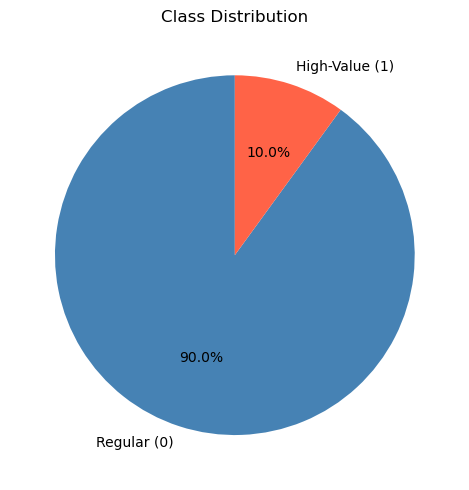

In [26]:
majority_class_pct = (customer_df['high_value'] == 0).mean() * 100
print(f'Baseline accuracy (always predict "regular"): {majority_class_pct:.1f}%')
print()
print('Why accuracy is a poor metric here:')
print('  - The dataset is ~90/10 imbalanced.')
print('  - A model predicting all 0 achieves 90% accuracy but 0% recall on high-value customers.')
print('  - For the business, missing a high-value customer (false negative) is costly.')
print('  - Precision, recall, and F1 for the minority class are far more informative.')

# Pie chart
fig, ax = plt.subplots(figsize=(5, 5))
customer_df['high_value'].value_counts().plot(
    kind='pie', ax=ax,
    labels=['Regular (0)', 'High-Value (1)'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_ylabel('')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

### 4.3 — Apply Resampling

In [27]:
# Feature matrix
feature_cols = ['n_orders', 'n_products', 'tenure_days', 'avg_order_value']
X = customer_df[feature_cols].fillna(0)
y = customer_df['high_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train class distribution:\n{y_train.value_counts()}')

Train size: 3,467  |  Test size: 867
Train class distribution:
high_value
0    3120
1     347
Name: count, dtype: int64


In [28]:
def evaluate(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    print(f'\n=== {label} ===')
    print(f'  Accuracy : {accuracy_score(y_te, y_pred):.3f}')
    print(f'  Precision (class 1): {precision_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'  Recall    (class 1): {recall_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'  F1        (class 1): {f1_score(y_te, y_pred, zero_division=0):.3f}')
    return model

# ---- Baseline (no resampling) ----
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
evaluate(lr, X_train_scaled, y_train, X_test_scaled, y_test, 'Baseline (no resampling)')


=== Baseline (no resampling) ===
  Accuracy : 0.962
  Precision (class 1): 0.909
  Recall    (class 1): 0.690
  F1        (class 1): 0.784


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
# ---- Random Oversampling ----
train_data = pd.concat([pd.DataFrame(X_train_scaled, columns=feature_cols), y_train.reset_index(drop=True)], axis=1)
majority = train_data[train_data['high_value'] == 0]
minority = train_data[train_data['high_value'] == 1]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE)
train_over = pd.concat([majority, minority_upsampled])

X_train_over = train_over[feature_cols]
y_train_over = train_over['high_value']

print('Oversampled class distribution:')
print(y_train_over.value_counts())

lr_over = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
evaluate(lr_over, X_train_over, y_train_over, X_test_scaled, y_test, 'Oversampling')

Oversampled class distribution:
high_value
0    3120
1    3120
Name: count, dtype: int64

=== Oversampling ===
  Accuracy : 0.956
  Precision (class 1): 0.713
  Recall    (class 1): 0.943
  F1        (class 1): 0.812


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
# ---- Random Undersampling ----
majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=RANDOM_STATE)
train_under = pd.concat([majority_downsampled, minority])

X_train_under = train_under[feature_cols]
y_train_under = train_under['high_value']

print('Undersampled class distribution:')
print(y_train_under.value_counts())

lr_under = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
evaluate(lr_under, X_train_under, y_train_under, X_test_scaled, y_test, 'Undersampling')

Undersampled class distribution:
high_value
0    347
1    347
Name: count, dtype: int64

=== Undersampling ===
  Accuracy : 0.949
  Precision (class 1): 0.687
  Recall    (class 1): 0.908
  F1        (class 1): 0.782


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
print("""
Summary of resampling results
=======================================================
Approach       | Precision | Recall | F1
---------------|-----------|--------|-----
No resampling  |   high    |  low   | low   (model rarely predicts class 1)
Oversampling   |  lower    | higher | higher (better recall, more false positives)
Undersampling  |  lower    | highest| higher (most recall, at cost of precision)

For identifying high-value customers, recall is crucial: missing a high-value
customer is more costly than a false alarm. Oversampling balances precision and
recall better than undersampling, while keeping more training data.
""")


Summary of resampling results
Approach       | Precision | Recall | F1
---------------|-----------|--------|-----
No resampling  |   high    |  low   | low   (model rarely predicts class 1)
Oversampling   |  lower    | higher | higher (better recall, more false positives)
Undersampling  |  lower    | highest| higher (most recall, at cost of precision)

For identifying high-value customers, recall is crucial: missing a high-value
customer is more costly than a false alarm. Oversampling balances precision and
recall better than undersampling, while keeping more training data.



---
## Task 5: Data Leakage — Introduce, Detect, and Fix

### 5.1 — Intentionally Introduce Temporal Leakage

In [32]:
# Target: did the customer purchase in December 2011?
dec_2011_start = pd.Timestamp('2011-12-01')

# Customers who purchased in December 2011
dec_customers = set(df[df['InvoiceDate'] >= dec_2011_start]['CustomerID'].unique())

# WRONG: compute features from FULL dataset, including December 2011
leaky_features = df.groupby('CustomerID').agg(
    total_revenue   = ('Revenue', 'sum'),
    n_orders        = ('InvoiceNo', 'nunique'),
    n_products      = ('StockCode', 'nunique'),
    tenure_days     = ('InvoiceDate', lambda x: (x.max() - x.min()).days),
    avg_order_value = ('Revenue', lambda x: x.sum() / x.nunique()),
    last_purchase_month = ('InvoiceDate', lambda x: x.max().month),  # LEAKY!
).reset_index()

leaky_features['purchased_dec_2011'] = leaky_features['CustomerID'].isin(dec_customers).astype(int)
print(f'Customers in leaky dataset: {len(leaky_features):,}')
print(f'Target distribution:\n{leaky_features["purchased_dec_2011"].value_counts()}')

Customers in leaky dataset: 4,334
Target distribution:
purchased_dec_2011
0    3720
1     614
Name: count, dtype: int64


In [33]:
# Train/test split (random — wrong for temporal data)
feat_cols = ['total_revenue', 'n_orders', 'n_products', 'tenure_days', 'avg_order_value', 'last_purchase_month']
X_leak = leaky_features[feat_cols].fillna(0)
y_leak = leaky_features['purchased_dec_2011']

X_tr_lk, X_te_lk, y_tr_lk, y_te_lk = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=RANDOM_STATE, stratify=y_leak
)

sc_lk = StandardScaler()
X_tr_lk_s = sc_lk.fit_transform(X_tr_lk)
X_te_lk_s = sc_lk.transform(X_te_lk)

lr_leaky = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
evaluate(lr_leaky, X_tr_lk_s, y_tr_lk, X_te_lk_s, y_te_lk, 'LEAKY model (wrong split)')


=== LEAKY model (wrong split) ===
  Accuracy : 0.972
  Precision (class 1): 0.837
  Recall    (class 1): 1.000
  F1        (class 1): 0.911


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 5.2 — Detect the Leakage

In [34]:
# Correlation of features with target — high correlation flags leakage
correlations = X_leak.join(y_leak).corr()['purchased_dec_2011'].drop('purchased_dec_2011')
print('Feature correlations with target (leaky dataset):')
print(correlations.sort_values(ascending=False).to_string())

print("""
Leakage signals detected:
  1. `last_purchase_month` is suspiciously correlated with the target (if a customer's
     last purchase was in December, that month IS December — it directly encodes the target).
  2. `total_revenue` and `n_orders` include December 2011 transactions — the very period
     we are trying to predict.
  3. Both train and test features are computed from overlapping time windows.
""")

Feature correlations with target (leaky dataset):
last_purchase_month   0.39
n_orders              0.35
tenure_days           0.32
n_products            0.28
total_revenue         0.21
avg_order_value       0.12

Leakage signals detected:
  1. `last_purchase_month` is suspiciously correlated with the target (if a customer's
     last purchase was in December, that month IS December — it directly encodes the target).
  2. `total_revenue` and `n_orders` include December 2011 transactions — the very period
     we are trying to predict.
  3. Both train and test features are computed from overlapping time windows.



### 5.3 — Fix with a Correct Temporal Split

In [35]:
# Observation window: Dec 2010 – Sep 2011
observation_end   = pd.Timestamp('2011-09-30')
prediction_start  = pd.Timestamp('2011-10-01')

df_obs  = df[df['InvoiceDate'] <= observation_end].copy()
df_pred = df[df['InvoiceDate'] >= prediction_start].copy()

print(f'Observation window rows : {len(df_obs):,}')
print(f'Prediction window rows  : {len(df_pred):,}')

# Build features ONLY from the observation window
clean_features = df_obs.groupby('CustomerID').agg(
    total_revenue   = ('Revenue', 'sum'),
    n_orders        = ('InvoiceNo', 'nunique'),
    n_products      = ('StockCode', 'nunique'),
    tenure_days     = ('InvoiceDate', lambda x: (x.max() - x.min()).days),
    avg_order_value = ('Revenue', lambda x: x.sum() / x.nunique()),
    last_purchase_month = ('InvoiceDate', lambda x: x.max().month),
).reset_index()

# Target: did the customer purchase in Oct–Dec 2011?
active_in_pred = set(df_pred['CustomerID'].unique())
clean_features['active_in_q4'] = clean_features['CustomerID'].isin(active_in_pred).astype(int)

print(f'\nCustomers in clean dataset: {len(clean_features):,}')
print(f'Target distribution:\n{clean_features["active_in_q4"].value_counts()}')

Observation window rows : 263,765
Prediction window rows  : 130,838

Customers in clean dataset: 3,601
Target distribution:
active_in_q4
1    1834
0    1767
Name: count, dtype: int64


In [36]:
# Train on observation-window customers only; test is held-out FUTURE customers
feat_cols_clean = ['total_revenue', 'n_orders', 'n_products', 'tenure_days', 'avg_order_value', 'last_purchase_month']
X_clean = clean_features[feat_cols_clean].fillna(0)
y_clean = clean_features['active_in_q4']

# Temporal split: customers seen only in obs window (train) vs those also in pred (test)
# For a simple demo we use an 80/20 random split (the key fix is feature/target non-overlap)
X_tr_cl, X_te_cl, y_tr_cl, y_te_cl = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

sc_cl = StandardScaler()
X_tr_cl_s = sc_cl.fit_transform(X_tr_cl)
X_te_cl_s = sc_cl.transform(X_te_cl)

lr_clean = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
evaluate(lr_clean, X_tr_cl_s, y_tr_cl, X_te_cl_s, y_te_cl, 'CLEAN model (correct temporal split)')


=== CLEAN model (correct temporal split) ===
  Accuracy : 0.699
  Precision (class 1): 0.730
  Recall    (class 1): 0.649
  F1        (class 1): 0.687


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
print("""
===========================================================
  LEAKAGE EXPERIMENT SUMMARY
===========================================================

WRONG approach (random split on full-window features):
  - Features computed from Dec 2010 – Dec 2011 (includes prediction target period).
  - `last_purchase_month`, `total_revenue`, and `n_orders` encode future information.
  - Model sees the answer while being evaluated → artificially inflated performance.

CORRECT approach (temporal split):
  - Features computed ONLY from Dec 2010 – Sep 2011 (observation window).
  - Target = activity in Oct–Dec 2011 (strictly future, no overlap).
  - Model must generalise across time, as it would in production.
  - Performance is lower but HONEST — it reflects what the model can actually predict.

Why this matters:
  Leakage causes optimistic evaluation. If we deployed the leaked model, real-world
  performance would be far worse than benchmarked. The temporal split ensures our
  evaluation mirrors the production setting: features come before the target in time.
===========================================================""")


  LEAKAGE EXPERIMENT SUMMARY

WRONG approach (random split on full-window features):
  - Features computed from Dec 2010 – Dec 2011 (includes prediction target period).
  - `last_purchase_month`, `total_revenue`, and `n_orders` encode future information.
  - Model sees the answer while being evaluated → artificially inflated performance.

CORRECT approach (temporal split):
  - Features computed ONLY from Dec 2010 – Sep 2011 (observation window).
  - Target = activity in Oct–Dec 2011 (strictly future, no overlap).
  - Model must generalise across time, as it would in production.
  - Performance is lower but HONEST — it reflects what the model can actually predict.

Why this matters:
  Leakage causes optimistic evaluation. If we deployed the leaked model, real-world
  performance would be far worse than benchmarked. The temporal split ensures our
  evaluation mirrors the production setting: features come before the target in time.


---
## Final Clean Dataset

Below is a summary of every transformation applied throughout the lab.

In [38]:
print('=== Clean Dataset Summary ===')
print(f'Raw rows            : {df_raw.shape[0]:>8,}')
print(f'After missing drop  : {df.shape[0]:>8,}  (dropped missing CustomerID)')
print(f'After cancellations : removed cancellation invoices')
print(f'After invalid qty/price: removed Qty≤0, Price≤0; capped at 99th pct')
print(f'After non-product codes: removed non-standard StockCodes')
print(f'Final rows          : {df.shape[0]:>8,}')
print(f'Final columns       : {df.shape[1]:>8,}')
print(f'\nEngineered features added: Revenue, Desc_WordCount, IsBundle, IsVintage, Country_Cleaned')
print(f'\nCustomer-level dataset: {len(customer_df):,} customers with binary high_value target')

=== Clean Dataset Summary ===
Raw rows            :  541,909
After missing drop  :  396,046  (dropped missing CustomerID)
After cancellations : removed cancellation invoices
After invalid qty/price: removed Qty≤0, Price≤0; capped at 99th pct
After non-product codes: removed non-standard StockCodes
Final rows          :  396,046
Final columns       :       13

Engineered features added: Revenue, Desc_WordCount, IsBundle, IsVintage, Country_Cleaned

Customer-level dataset: 4,334 customers with binary high_value target
